##Parte teórica


1. Descreva o funcionamento da planta do grupo. Quais sensores, atuadores podem
ser utilizados em um desenvolvimento real do controlador.
2. Identifique a variável controlada (o que se deseja regular), a variável manipulada (onde se atua), as principais perturbações e as faixas reais de operação de cada uma.


## Parte prática do trabalho
1. Identifique o conjunto de dados para seu grupo, resultantes de Ensaios simulados da Curva de Reação, nomeado por 'Dataset GrupoX';
2. Escolha entre os Método de Identificação da Planta - Smith ou Sundaresan, e determine os valores de k, t e O para levantar a Função de Transferência do modelo de acordo com a resposta típica. Justifique a escolha do método e do modelo;
3. Compare a resposta original em relação à estimada e verifique se a aproximação foi satisfatória. Se necessário, realize o ajuste fino dos parâmetros, expondo o reflexo das alterações na resposta do sistema;
4. Plote as respostas do Sistema em Malha Aberta e Fechada e comente sobre as diferenças nos Tempos
de subida e de acomodação e no erro do processo;
5. Sintonize um Controlador PID de acordo com os métodos especificados para seu grupo na
Tabelas 7 e 8 e verifique o comportamento do sistema controlado. Para a Sintonia IMC, a escolha de d é livre de acordo com o desempenho desejado. Justifique o valor escolhido para o parâmetro.

In [4]:
# Identificação do conjunto de dados - Penumático G4

from scipy.io import loadmat
from google.colab import drive
drive.mount('/content/drive')

dados = loadmat('/content/drive/MyDrive/EngComputInatel/C013_SistEmbarcados/Pneumático_G4.mat')

print(dados.keys())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dict_keys(['__header__', '__version__', '__globals__', 'Degrau', 'Saida', 't', 'unidade_saida', 'parametros', 'descricao'])


In [5]:
t = dados['t'].squeeze()
entrada = dados['Degrau'].squeeze()
saida = dados['Saida'].squeeze()

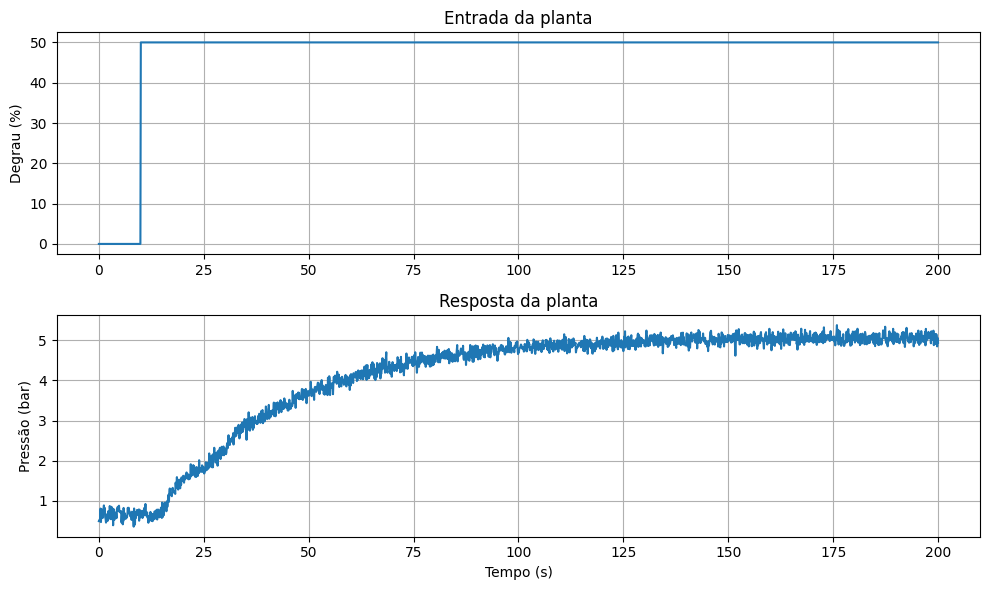

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, entrada)
plt.grid()
plt.ylabel('Degrau (%)')
plt.title('Entrada da planta')

plt.subplot(2, 1, 2)
plt.plot(t, saida)
plt.grid()
plt.xlabel('Tempo (s)')
plt.ylabel('Pressão (bar)')
plt.title('Resposta da planta')

plt.tight_layout()
plt.show()

### Identificação da Planta:

Pela resposta ao degrau, nosso sistema é um **modelo de Primeira Ordem com atraso (FOPDT)**, caracterizado por três parâmetros:

*   **Ganho de Processo (k):** Representa a relação entre a mudança na saída em regime permanente e a mudança na entrada em regime permanente.
*   **Constante de Tempo (τ):** Indica a velocidade de resposta do processo a uma mudança na entrada. É o tempo que o sistema leva para atingir 63.2% de sua mudança total na saída após uma mudança degrau na entrada, na ausência de atraso.
*   **Tempo Morto (θ):** Representa o atraso entre o momento em que a entrada muda e o momento em que a saída começa a responder.

A função de transferência para esse modelo é dada por:

$$ G(s) = \frac{K e^{-\theta s}}{\tau s + 1} $$



**Método de Sundaresan e Krishnaswamy para Identificação:**

Este método é uma técnica gráfica para determinar os parâmetros $K$, $\tau$ e $\theta$ de um modelo FOPDT a partir da resposta a um degrau. Ele é considerado robusto e adequado para respostas que não começam imediatamente do zero ou têm algum ruído. Ele será utilizado devido à sua capacidade de extrair parâmetros de forma eficaz de respostas degrau experimentais, que muitas vezes possuem características como tempo morto e uma curva de reação S-formato.

Os passos são:
1.  **Calcular o Ganho (K):** $K = \frac{\Delta Saída}{\Delta Entrada} = \frac{Saída_{final} - Saída_{inicial}}{Entrada_{final} - Entrada_{inicial}}$.
2.  **Identificar $t_1$ e $t_2$:** Encontre os tempos em que a resposta atinge 35.3% e 85.3% da mudança total na saída (acima da saída inicial).
3.  **Calcular $\tau$ e $\theta$:**
    *   $\tau = 0.67 (t_2 - t_1)$
    *   $\theta = 1.3 t_1 - 0.29 \tau$



Ganho (K): 0.0890
Tempo t1 (35.3%): 26.30 s
Tempo t2 (85.3%): 63.30 s
Constante de Tempo (tau): 24.7900 s
Tempo Morto (theta): 27.0009 s


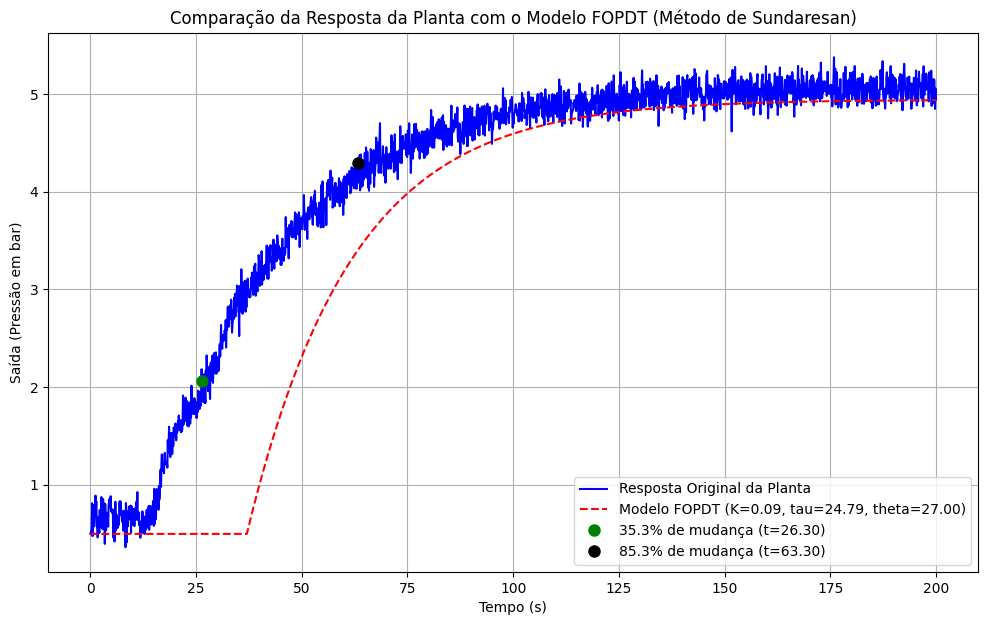

In [7]:
import numpy as np
from scipy.integrate import odeint

# 1. Calcular o Ganho (K)
entrada_inicial = entrada[0]
entrada_final = entrada[-1]

saida_inicial = saida[0]
saida_final = saida[-1]

delta_entrada = entrada_final - entrada_inicial
delta_saida = saida_final - saida_inicial

K = delta_saida / delta_entrada

print(f"Ganho (K): {K:.4f}")

# 2. Identificar t1 e t2 (Método de Sundaresan e Krishnaswamy)
total_change_saida = saida_final - saida_inicial

# Valores da saida para 35.3% e 85.3% da mudança total
val_35_3_percent = saida_inicial + 0.353 * total_change_saida
val_85_3_percent = saida_inicial + 0.853 * total_change_saida

# Encontrar os tempos correspondentes
t1_idx = np.where(saida >= val_35_3_percent)[0][0]
t1 = t[t1_idx]

t2_idx = np.where(saida >= val_85_3_percent)[0][0]
t2 = t[t2_idx]

print(f"Tempo t1 (35.3%): {t1:.2f} s")
print(f"Tempo t2 (85.3%): {t2:.2f} s")

# 3. Calcular tau e theta
tau = 0.67 * (t2 - t1)
theta = 1.3 * t1 - 0.29 * tau

print(f"Constante de Tempo (tau): {tau:.4f} s")
print(f"Tempo Morto (theta): {theta:.4f} s")

# Modelo FOPDT
def fopdt_model(y, t, K, tau, theta_eff, input_func, entrada_offset, saida_offset):
    if t - theta_eff < 0:
        u_delayed = entrada_offset
    else:
        u_delayed = input_func(t - theta_eff)
    dydt = (-y + K * (u_delayed - entrada_offset) + saida_offset) / tau
    return dydt

# Criar uma função de interpolação para a entrada degrau
from scipy.interpolate import interp1d
input_step_func = interp1d(t, entrada, kind='previous', fill_value="extrapolate")

# Simular a resposta do modelo FOPDT
y0 = saida_inicial # Condição inicial

saida_modelo_fopdt = odeint(fopdt_model, y0, t, args=(K, tau, theta, input_step_func, entrada_inicial, saida_inicial))

# Resposta original e a resposta do modelo
plt.figure(figsize=(12, 7))
plt.plot(t, saida, 'b-', label='Resposta Original da Planta')
plt.plot(t, saida_modelo_fopdt, 'r--', label=f'Modelo FOPDT (K={K:.2f}, tau={tau:.2f}, theta={theta:.2f})')
plt.plot(t1, val_35_3_percent, 'go', markersize=8, label=f'35.3% de mudança (t={t1:.2f})')
plt.plot(t2, val_85_3_percent, 'ko', markersize=8, label=f'85.3% de mudança (t={t2:.2f})')
plt.title('Comparação da Resposta da Planta com o Modelo FOPDT (Método de Sundaresan)')
plt.xlabel('Tempo (s)')
plt.ylabel('Saída (Pressão em bar)')
plt.grid(True)
plt.legend()
plt.show()